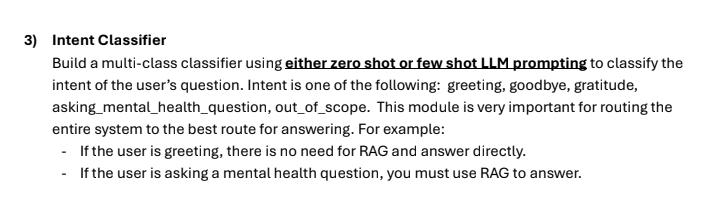

In [ ]:
from typing import Literal
import groq
import instructor
from pydantic import BaseModel, Field

In [ ]:
intent_category = Literal["greeting", "goodbye", "gratitude", "asking_mental_health_question", "out_of_scope"]

class IntentResponse(BaseModel):
    intent:intent_category = Field(description="The strictly classified intent of the user's query.")
    confidence:float = Field(description="Confidence score for this classification, between 0.0 and 1.0")

In [9]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
client = instructor.from_groq(groq.Groq())

In [10]:
def classify_user_intent(user_query:str)->IntentResponse:
    response = client.chat.completions.create(
        model = "meta-llama/llama-4-scout-17b-16e-instruct",
        response_model= IntentResponse,
        messages=[
         {
                "role": "system", 
                "content": (
                    "You are an expert intent classifier for a mental health chatbot. "
                    "Classify the user's input into one of the predefined categories.\n\n"
                    "Here are some examples to guide you:\n"
                    "- User: 'سلام عليكم، صبّاح الخير' -> intent: 'greeting', confidence: 1.0\n"
                    "- User: 'hello there, good morning' -> intent: 'greeting', confidence: 1.0\n"
                    "- User: 'أنا بحس بـ خنقة وضيق في التنفس بقالي يومين' -> intent: 'asking_mental_health_question', confidence: 0.97\n"
                    "- User: 'I feel very anxious and can't sleep' -> intent: 'asking_mental_health_question', confidence: 0.98\n"
                    "- User: 'تسلم يا غالي شكراً ليك' -> intent: 'gratitude', confidence: 1.0\n"
                    "- User: 'أقرب مطعم بيتزا فين؟' -> intent: 'out_of_scope', confidence: 1.0\n"
                )
            },
            
            
            {"role": "user", "content": user_query}
        ]
    )
    return response

In [11]:
res = classify_user_intent("Hey there, is anyone available?")
print(res.intent)
print(res.confidence)

greeting
0.99


In [ ]:
res = classify_user_intent("بقالي أسبوع مش جالي نوم خالص وحاسس بضيق في صدري من غير سبب")
print(res.intent)
print(res.confidence)



asking_mental_health_question
0.98


In [13]:
# Thanks, that was very helpful

res = classify_user_intent("Thanks, that was very helpful")
print(res.intent)
print(res.confidence)

gratitude
1.0


In [ ]:
#test
res = classify_user_intent("Can you give me a recipe for making pizza?")
print(res.intent)
print(res.confidence)

out_of_scope
1.0


In [ ]:
res = classify_user_intent("اكتبلي كود بايثون يعمل ايميل لمديري?")
print(res.intent)